<a href="https://colab.research.google.com/github/bhoomikanaidu1007/PFBA/blob/main/Project_1_Python_sales_analyzer_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# below files / code will be based on project 1 e-commerce

In [5]:
# importing pandas / module to my python interpreter - language processor.
# exel in py
import pandas as pd  #pd ka mtlab pandas ka shortform
import matplotlib.pyplot as plt            # Data visualization
import matplotlib.ticker as mticker        # Formatting chart axes

In [6]:
df = pd.read_csv('sales_data_raw.csv')

In [7]:
df.shape

(1050, 8)

In [8]:
df_clean = pd.read_csv( 'cleaned_sales.csv')

In [9]:
df_clean.shape

(970, 11)

In [10]:
df.describe()

,Quantity,Unit_Price,Discount
count,1050.000000,1020.000000,965.000000
mean,2.977143,9639.630010,7.145078
std,1.420083,12243.319571,7.422468
min,1.000000,203.220000,0.000000
25%,2.000000,1440.300000,0.000000
50%,3.000000,4310.250000,5.000000
75%,4.000000,11470.990000,15.000000
max,5.000000,49930.450000,20.000000


In [11]:
df.head()

,Order_ID,Order_Date,Customer_Name,Product_Category,Quantity,Unit_Price,Discount,Region
0,ORD-10524,2024-05-09,Sneha Kumar,Books,5,592.79,20.0,West
1,ORD-10254,2024-07-04,Arjun Verma,Clothing,2,1046.13,20.0,South
2,ORD-10832,2024-06-08,Rahul Mishra,Electronics,1,43165.58,0.0,West
3,ORD-10343,2024-07-30,Amit Mishra,Electronics,2,15414.50,0.0,South
4,ORD-10601,2024-11-12,Arjun Kumar,Clothing,1,4984.84,0.0,East


In [12]:
df_clean.head()

,Order_ID,Order_Date,Customer_Name,Product_Category,Quantity,Unit_Price,Discount,Region,Revenue,Month,Month_Name
0,ORD-10524,2024-05-09,Sneha Kumar,Books,5,592.79,20.0,West,2371.16,5,May
1,ORD-10254,2024-07-04,Arjun Verma,Clothing,2,1046.13,20.0,South,1673.81,7,Jul
2,ORD-10832,2024-06-08,Rahul Mishra,Electronics,1,43165.58,0.0,West,43165.58,6,Jun
3,ORD-10343,2024-07-30,Amit Mishra,Electronics,2,15414.50,0.0,South,30829.00,7,Jul
4,ORD-10601,2024-11-12,Arjun Kumar,Clothing,1,4984.84,0.0,East,4984.84,11,Nov


In [13]:
df_clean.describe()

,Quantity,Unit_Price,Discount,Revenue,Month
count,970.000000,970.000000,970.000000,970.000000,970.000000
mean,2.988660,9726.460412,6.432990,27145.566237,6.727835
std,1.423986,12344.374455,7.343703,40771.105294,3.485211
min,1.000000,203.220000,0.000000,172.740000,1.000000
25%,2.000000,1452.135000,0.000000,3670.685000,4.000000
50%,3.000000,4310.250000,5.000000,11040.415000,7.000000
75%,4.000000,11741.735000,10.000000,29931.910000,10.000000
max,5.000000,49930.450000,20.000000,233380.800000,12.000000


# Task 1 Data Loading & Inspecting

Objective: Load the CSV file and understand its structure before touching any data.

🔑 Business Rule: Never modify raw data directly. Always load it into a DataFrame first and inspect it thoroughly. A senior analyst always asks:

How many rows and columns do I have?
What are the data types?
Where are the missing values?
Are there duplicates?

In [14]:
# ── Step 1a: Load the CSV ─────────────────────────────────────────────────────
df = pd.read_csv('sales_data_raw.csv')

print('=' * 55)
print('  DATASET LOADED SUCCESSFULLY')
print('=' * 55)
print(f'  Rows    : {df.shape[0]:,}')
print(f'  Columns : {df.shape[1]}')
print('=' * 55)

  DATASET LOADED SUCCESSFULLY
  Rows    : 1,050
  Columns : 8


In [15]:
# ── Step 1b: Preview the first 5 rows ────────────────────────────────────────
# head() shows the top rows — like opening the file and glancing at it
print('--- First 5 rows of the dataset ---')
df.head()

--- First 5 rows of the dataset ---


,Order_ID,Order_Date,Customer_Name,Product_Category,Quantity,Unit_Price,Discount,Region
0,ORD-10524,2024-05-09,Sneha Kumar,Books,5,592.79,20.0,West
1,ORD-10254,2024-07-04,Arjun Verma,Clothing,2,1046.13,20.0,South
2,ORD-10832,2024-06-08,Rahul Mishra,Electronics,1,43165.58,0.0,West
3,ORD-10343,2024-07-30,Amit Mishra,Electronics,2,15414.50,0.0,South
4,ORD-10601,2024-11-12,Arjun Kumar,Clothing,1,4984.84,0.0,East


In [16]:
# ── Step 1c: Check data types and non-null counts ─────────────────────────────
# info() tells us the data type of each column and how many non-null values exist
# Non-null count < total rows  →  that column has MISSING VALUES
print('--- Dataset Information (Data Types & Missing Value Check) ---')
df.info()

--- Dataset Information (Data Types & Missing Value Check) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          1050 non-null   object 
 1   Order_Date        1050 non-null   object 
 2   Customer_Name     999 non-null    object 
 3   Product_Category  1050 non-null   object 
 4   Quantity          1050 non-null   int64  
 5   Unit_Price        1020 non-null   float64
 6   Discount          965 non-null    float64
 7   Region            1050 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.8+ KB


In [17]:
# ── Step 1d: Descriptive statistics ──────────────────────────────────────────
# describe() gives us count, mean, min, max for numeric columns
# This is a quick 'health check' for the numbers
print('--- Descriptive Statistics ---')
df.describe()

--- Descriptive Statistics ---


,Quantity,Unit_Price,Discount
count,1050.000000,1020.000000,965.000000
mean,2.977143,9639.630010,7.145078
std,1.420083,12243.319571,7.422468
min,1.000000,203.220000,0.000000
25%,2.000000,1440.300000,0.000000
50%,3.000000,4310.250000,5.000000
75%,4.000000,11470.990000,15.000000
max,5.000000,49930.450000,20.000000


In [18]:
# ── Step 1e: Count missing values per column ──────────────────────────────────
# isnull() returns True/False for each cell → .sum() counts the Trues per column
missing_counts = df.isnull().sum()
missing_pct    = (df.isnull().sum() / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    'Missing Count'  : missing_counts,
    'Missing %'      : missing_pct
}).query('`Missing Count` > 0')   # show only columns that have missing values

print('--- Missing Values Summary ---')
print(missing_summary.to_string())
print()
print(f'Duplicate rows found: {df.duplicated().sum()}')

--- Missing Values Summary ---
               Missing Count  Missing %
Customer_Name             51       4.86
Unit_Price                30       2.86
Discount                  85       8.10

Duplicate rows found: 50


---
## 🧹 Task 2 — Data Cleaning

**Objective:** Fix all data quality issues before any analysis.

### Cleaning Rules (Business Decisions)
| Issue | Column | Action | Why |
|-------|--------|--------|-----|
| Missing values | `Unit_Price` | **Drop the row** | We cannot calculate revenue without a price |
| Missing values | `Customer_Name` | **Fill with `"Unknown"`** | Orders are still valid; customer is just anonymous |
| Missing values | `Discount` | **Fill with `0`** | No discount info = no discount was applied |
| Duplicate rows | All columns | **Drop duplicates** | Same order appearing twice inflates revenue figures |

> 💡 **Key Insight:** Data cleaning decisions are **business decisions**, not just technical ones.
> Always justify *why* you chose to drop vs. fill.

In [19]:
# ── Step 2: Data Cleaning ─────────────────────────────────────────────────────

rows_before = len(df)
print(f'Rows BEFORE cleaning: {rows_before:,}')
print('-' * 40)

# 2a. Drop rows where Unit_Price is missing (cannot calculate revenue)
df = df.dropna(subset=['Unit_Price'])
print(f'After dropping missing Unit_Price  : {len(df):,} rows  (-{rows_before - len(df)} rows dropped)')

# 2b. Fill missing Customer_Name with 'Unknown'
missing_names = df['Customer_Name'].isnull().sum()
df['Customer_Name'] = df['Customer_Name'].fillna('Unknown')
print(f'Customer_Name  → filled {missing_names} missing values with "Unknown"')

# 2c. Fill missing Discount with 0 (no discount info = no discount)
missing_disc = df['Discount'].isnull().sum()
df['Discount'] = df['Discount'].fillna(0)
print(f'Discount       → filled {missing_disc} missing values with 0')

# 2d. Remove duplicate rows
before_dedup = len(df)
df = df.drop_duplicates()
print(f'Duplicates     → removed {before_dedup - len(df)} duplicate rows')

print('-' * 40)
print(f'Rows AFTER  cleaning: {len(df):,}')
print()

# Verify: no more missing values
remaining_nulls = df.isnull().sum().sum()
print(f'✅ Remaining missing values: {remaining_nulls}  ← should be 0')

Rows BEFORE cleaning: 1,050
----------------------------------------
After dropping missing Unit_Price  : 1,020 rows  (-30 rows dropped)
Customer_Name  → filled 51 missing values with "Unknown"
Discount       → filled 83 missing values with 0
Duplicates     → removed 50 duplicate rows
----------------------------------------
Rows AFTER  cleaning: 970

✅ Remaining missing values: 0  ← should be 0


---
## ⚙️ Task 3 — Feature Engineering

**Objective:** Create new columns that unlock deeper business insights.

Feature Engineering means **creating new, useful columns from existing data**.
We will create two new columns:
1. **`Revenue`** — the actual money earned per order (after discount)
2. **`Month`** — extracted from `Order_Date` to enable monthly trend analysis

> 💡 **Why Revenue and not just Unit_Price?**
> A ₹10,000 order with a 20% discount only generates ₹8,000 in actual revenue.
> Using Unit_Price alone would **overstate** the company's earnings.

In [20]:
# ── Step 3: Feature Engineering ───────────────────────────────────────────────

# 3a. Convert Order_Date from string to proper datetime format
#     pd.to_datetime() lets Python understand dates (not just text)
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
print(f'Order_Date dtype after conversion: {df["Order_Date"].dtype}  ✅')

# 3b. Create Revenue column
#     Formula: Revenue = Quantity × Unit_Price × (1 - Discount/100)
#     The (1 - Discount/100) part applies the discount percentage
df['Revenue'] = df['Quantity'] * df['Unit_Price'] * (1 - df['Discount'] / 100)
df['Revenue'] = df['Revenue'].round(2)

# 3c. Extract Month number (1=Jan, 2=Feb, ... 12=Dec) from Order_Date
df['Month'] = df['Order_Date'].dt.month

# 3d. Create a Month Name column for readable chart labels
month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
df['Month_Name'] = df['Month'].map(month_names)

print()
print('--- Preview with new columns ---')
df[['Order_ID', 'Order_Date', 'Quantity', 'Unit_Price', 'Discount', 'Revenue', 'Month', 'Month_Name']].head(8)


Order_Date dtype after conversion: datetime64[ns]  ✅

--- Preview with new columns ---


,Order_ID,Order_Date,Quantity,Unit_Price,Discount,Revenue,Month,Month_Name
0,ORD-10524,2024-05-09,5,592.79,20.0,2371.16,5,May
1,ORD-10254,2024-07-04,2,1046.13,20.0,1673.81,7,Jul
2,ORD-10832,2024-06-08,1,43165.58,0.0,43165.58,6,Jun
3,ORD-10343,2024-07-30,2,15414.50,0.0,30829.00,7,Jul
4,ORD-10601,2024-11-12,1,4984.84,0.0,4984.84,11,Nov
5,ORD-10559,2024-03-11,3,12673.05,5.0,36118.19,3,Mar
6,ORD-10316,2024-08-04,1,7869.20,0.0,7869.20,8,Aug
7,ORD-10358,2024-01-16,4,11926.38,5.0,45320.24,1,Jan


In [21]:
# ── Quick Revenue Sanity Check ────────────────────────────────────────────────
total_revenue = df['Revenue'].sum()
avg_order_val = df['Revenue'].mean()
max_order_val = df['Revenue'].max()

print('📊 Revenue Overview')
print('=' * 40)
print(f'  Total Annual Revenue  : ₹{total_revenue:>15,.2f}')
print(f'  Average Order Value   : ₹{avg_order_val:>15,.2f}')
print(f'  Largest Single Order  : ₹{max_order_val:>15,.2f}')
print(f'  Total Orders Analyzed : {len(df):>15,}')
print('=' * 40)


📊 Revenue Overview
  Total Annual Revenue  : ₹  26,331,199.25
  Average Order Value   : ₹      27,145.57
  Largest Single Order  : ₹     233,380.80
  Total Orders Analyzed :             970


---
## 📊 Task 4 — Sales Analysis

**Objective:** Answer key business questions using `groupby` aggregation.

`groupby` is one of the most powerful tools in Pandas. It works exactly like a Pivot Table in Excel:
**group the data by a category, then calculate a summary statistic for each group.**

### Business Questions We Will Answer:
1. Which product category generates the most revenue?
2. Which region contributes the most to total sales?
3. Which month was the best for the company?
4. What is the average order value per product category?

In [22]:
# ── Step 4a: Revenue by Product Category ─────────────────────────────────────
category_revenue = (
    df.groupby('Product_Category')['Revenue']
    .agg(['sum', 'mean', 'count'])
    .rename(columns={'sum': 'Total Revenue (₹)', 'mean': 'Avg Order Value (₹)', 'count': 'No. of Orders'})
    .sort_values('Total Revenue (₹)', ascending=False)
    .round(2)
)

# Add revenue share %
category_revenue['Revenue Share (%)'] = (
    category_revenue['Total Revenue (₹)'] / category_revenue['Total Revenue (₹)'].sum() * 100
).round(2)

print('--- Revenue by Product Category ---')
category_revenue

--- Revenue by Product Category ---


,Total Revenue (₹),Avg Order Value (₹),No. of Orders,Revenue Share (%)
Product_Category,,,,
Electronics,17871743.65,79784.57,224,67.87
Home & Kitchen,4227285.06,22366.59,189,16.05
Sports,2234104.72,12551.15,178,8.48
Clothing,1564597.81,8191.61,191,5.94
Books,433468.01,2305.68,188,1.65


In [23]:
# ── Step 4b: Revenue by Region ────────────────────────────────────────────────
region_revenue = (
    df.groupby('Region')['Revenue']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'Total Revenue (₹)', 'count': 'No. of Orders'})
    .sort_values('Total Revenue (₹)', ascending=False)
    .round(2)
)

region_revenue['Revenue Share (%)'] = (
    region_revenue['Total Revenue (₹)'] / region_revenue['Total Revenue (₹)'].sum() * 100
).round(2)

print('--- Revenue by Region ---')
region_revenue

--- Revenue by Region ---


,Total Revenue (₹),No. of Orders,Revenue Share (%)
Region,,,
North,7580354.14,238,28.79
South,6657215.15,243,25.28
West,6516843.89,251,24.75
East,5576786.07,238,21.18


In [24]:
# ── Step 4c: Monthly Revenue Trend ───────────────────────────────────────────
monthly_revenue = (
    df.groupby(['Month', 'Month_Name'])['Revenue']
    .sum()
    .reset_index()
    .sort_values('Month')       # ensure chronological order
    .round(2)
)

# Find the peak month
peak_month     = monthly_revenue.loc[monthly_revenue['Revenue'].idxmax()]
weakest_month  = monthly_revenue.loc[monthly_revenue['Revenue'].idxmin()]

print('--- Monthly Revenue Summary ---')
print(monthly_revenue[['Month_Name', 'Revenue']].to_string(index=False))
print()
print(f'🏆 Peak Month   : {peak_month["Month_Name"]}  →  ₹{peak_month["Revenue"]:,.2f}')
print(f'📉 Weakest Month: {weakest_month["Month_Name"]}  →  ₹{weakest_month["Revenue"]:,.2f}')

--- Monthly Revenue Summary ---
Month_Name    Revenue
       Jan 2722578.85
       Feb 2000142.73
       Mar 1960838.72
       Apr 1811701.48
       May 2248760.95
       Jun 1963405.76
       Jul 1872160.45
       Aug 2668256.61
       Sep 1729339.72
       Oct 2432312.73
       Nov 2563411.29
       Dec 2358289.96

🏆 Peak Month   : Jan  →  ₹2,722,578.85
📉 Weakest Month: Sep  →  ₹1,729,339.72


---
## 📈 Task 5 — Visualization

**Objective:** Turn the analysis into professional, presentation-ready charts.

We will create **three charts** that a business manager can immediately understand:

| Chart | Type | Business Question |
|-------|------|-------------------|
| Chart 1 | Line Chart | How did revenue trend across months? |
| Chart 2 | Horizontal Bar Chart | Which categories generated the most revenue? |
| Chart 3 | Pie Chart | What share of revenue came from each region? |

> 🎨 **Design Rules for Business Charts:**
> - Always add a **title** (what the chart shows)
> - Always label your **axes** (what the numbers mean)
> - Use **consistent colors** that are easy to distinguish
> - Add **data labels** so readers don't have to guess values
> - Keep it **clean** — remove unnecessary gridlines and borders

✅ Chart 1 saved as  chart1_monthly_trend.png


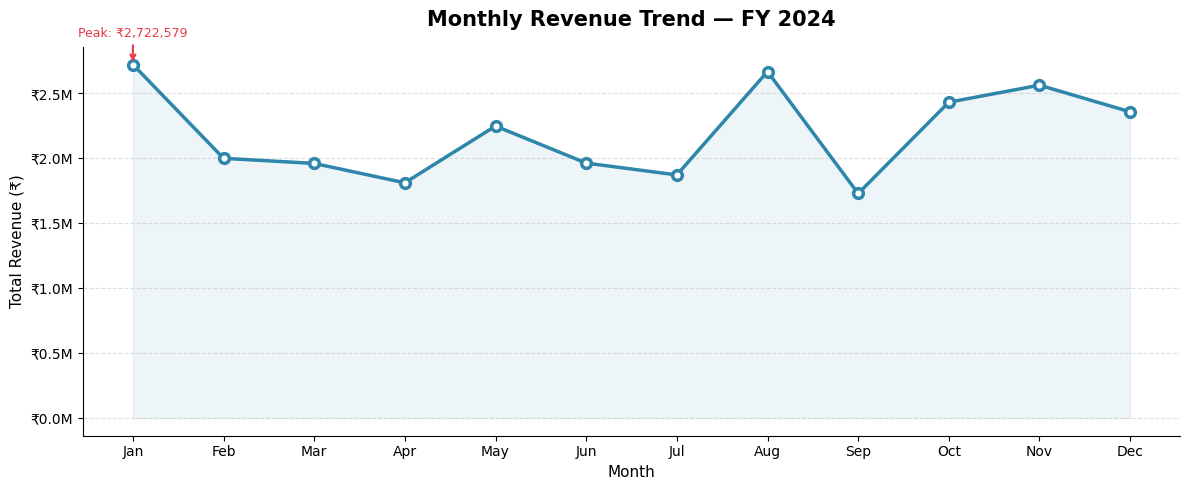

In [25]:
# ── Chart 1: Monthly Revenue Trend (Line Chart) ───────────────────────────────

fig, ax = plt.subplots(figsize=(12, 5))

# Plot the line
ax.plot(
    monthly_revenue['Month_Name'],
    monthly_revenue['Revenue'],
    color='#2E86AB',
    linewidth=2.5,
    marker='o',          # circle at each data point
    markersize=7,
    markerfacecolor='white',
    markeredgewidth=2.5,
    label='Monthly Revenue'
)

# Shade the area under the line
ax.fill_between(
    monthly_revenue['Month_Name'],
    monthly_revenue['Revenue'],
    alpha=0.08,
    color='#2E86AB'
)

# Highlight the peak month
peak_idx = monthly_revenue['Revenue'].idxmax()
ax.annotate(
    f"Peak: ₹{monthly_revenue.loc[peak_idx, 'Revenue']:,.0f}",
    xy=(peak_idx, monthly_revenue.loc[peak_idx, 'Revenue']),
    xytext=(0, 20), textcoords='offset points',
    ha='center', fontsize=9, color='#E63946',
    arrowprops=dict(arrowstyle='->', color='#E63946', lw=1.5)
)

# Formatting
ax.set_title('Monthly Revenue Trend — FY 2024', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Total Revenue (₹)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=0, fontsize=10)
plt.tight_layout()

plt.savefig('chart1_monthly_trend.png', dpi=150, bbox_inches='tight')
print('✅ Chart 1 saved as  chart1_monthly_trend.png')
plt.show()

✅ Chart 2 saved as  chart2_category_revenue.png


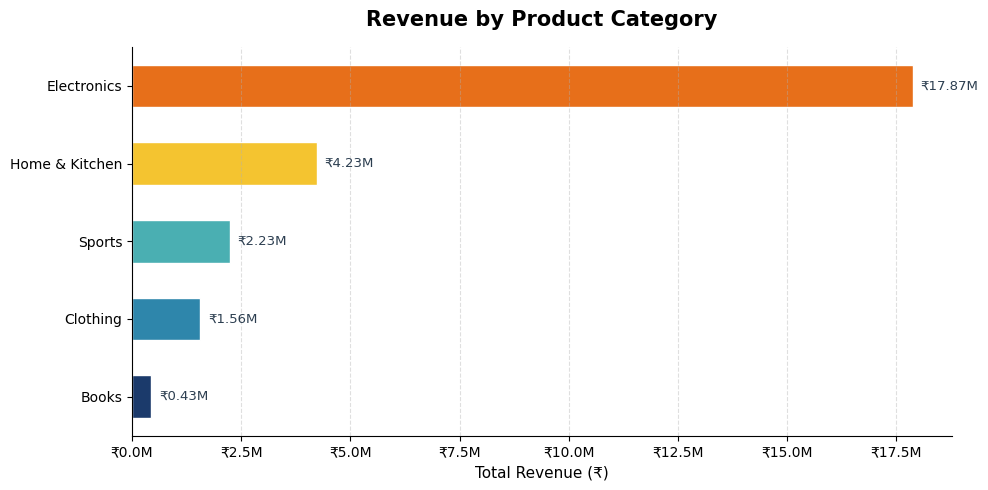

In [26]:
# ── Chart 2: Revenue by Product Category (Horizontal Bar Chart) ───────────────

# Sort ascending so highest bar appears at top
cat_sorted = category_revenue.sort_values('Total Revenue (₹)', ascending=True)

colors = ['#1B3A6B', '#2E86AB', '#4AAFB2', '#F4C430', '#E76F1A']

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    cat_sorted.index,
    cat_sorted['Total Revenue (₹)'],
    color=colors,
    edgecolor='white',
    height=0.55
)

# Add value labels at end of each bar
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + (cat_sorted['Total Revenue (₹)'].max() * 0.01),
        bar.get_y() + bar.get_height() / 2,
        f'₹{width/1e6:.2f}M',
        va='center', ha='left', fontsize=9.5, color='#2C3E50'
    )

# Formatting
ax.set_title('Revenue by Product Category', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Total Revenue (₹)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.savefig('chart2_category_revenue.png', dpi=150, bbox_inches='tight')
print('✅ Chart 2 saved as  chart2_category_revenue.png')
plt.show()

✅ Chart 3 saved as  chart3_regional_share.png


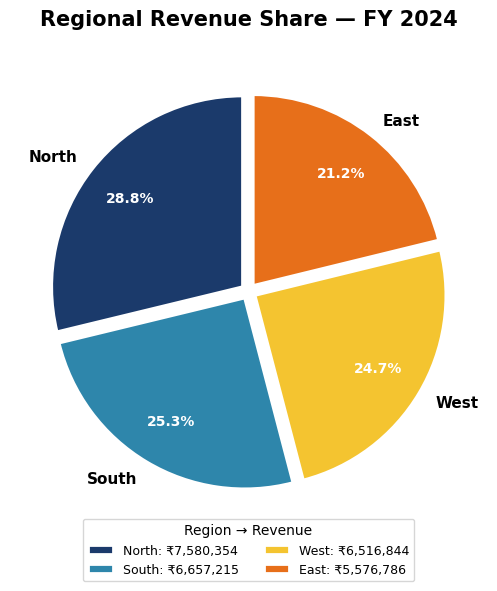

In [27]:
# ── Chart 3: Regional Revenue Share (Pie Chart) ───────────────────────────────

region_colors = ['#1B3A6B', '#2E86AB', '#F4C430', '#E76F1A']
explode       = [0.04] * len(region_revenue)   # slight separation for all slices

fig, ax = plt.subplots(figsize=(8, 6))

wedges, texts, autotexts = ax.pie(
    region_revenue['Total Revenue (₹)'],
    labels=region_revenue.index,
    autopct='%1.1f%%',
    colors=region_colors,
    explode=explode,
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# Style the text
for text in texts:
    text.set_fontsize(11)
    text.set_fontweight('bold')
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title('Regional Revenue Share — FY 2024', fontsize=15, fontweight='bold', pad=20)

# Add revenue values as legend entries
legend_labels = [
    f"{region}: ₹{rev:,.0f}"
    for region, rev in zip(region_revenue.index, region_revenue['Total Revenue (₹)'])
]
ax.legend(wedges, legend_labels, title='Region → Revenue', loc='lower center',
          bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=9)

plt.tight_layout()
plt.savefig('chart3_regional_share.png', dpi=150, bbox_inches='tight')
print('✅ Chart 3 saved as  chart3_regional_share.png')
plt.show()